# Feature Engineering & Forecast Design

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

ML_DIR = PROCESSED_DIR / "ml"

ML_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORTS_DIR = PROJECT_ROOT / "reports"

TABLES_DIR = (
    REPORTS_DIR /
    "tables" /
    "phase8_ml_preparation"
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
hourly = pd.read_csv(
    PROCESSED_DIR /
    "air_quality_features.csv",
    parse_dates=['time'],
    index_col='time'
)

In [4]:
print(
    "Shape:",
    hourly.shape
)

print(
    "Period:",
    hourly.index.min(),
    "to",
    hourly.index.max()
)

print(
    "Frequency:",
    pd.infer_freq(
        hourly.index
    )
)

print(
    "Missing:",
    hourly.isna().sum().sum()
)

Shape: (23352, 43)
Period: 2022-09-01 00:00:00 to 2025-04-30 23:00:00
Frequency: h
Missing: 0


In [5]:
FORECAST_HORIZON = 24

In [6]:
ml_df = hourly.copy()

## Forecasting target

In [7]:
#Target PM2.5
ml_df[
    'target_pm25_24h'
] = (
    ml_df['pm25']
    .shift(
        -FORECAST_HORIZON
    )
)

In [8]:
ml_df[
    'target_time'
] = (
    ml_df.index
    + pd.Timedelta(
        hours=FORECAST_HORIZON
    )
)

In [9]:
ml_df[
    [
        'pm25',
        'target_pm25_24h',
        'target_time'
    ]
].head(30)

,pm25,target_pm25_24h,target_time
time,,,
2022-09-01 00:00:00,37.1,25.3,2022-09-02 00:00:00
2022-09-01 01:00:00,36.2,26.3,2022-09-02 01:00:00
2022-09-01 02:00:00,35.5,27.9,2022-09-02 02:00:00
2022-09-01 03:00:00,34.8,29.9,2022-09-02 03:00:00
2022-09-01 04:00:00,33.1,29.7,2022-09-02 04:00:00
2022-09-01 05:00:00,27.6,33.6,2022-09-02 05:00:00
2022-09-01 06:00:00,26.1,29.4,2022-09-02 06:00:00
2022-09-01 07:00:00,22.7,21.9,2022-09-02 07:00:00
2022-09-01 08:00:00,20.7,19.3,2022-09-02 08:00:00


In [10]:
#target alignment
test_time = ml_df.index[100]

expected_target_time = (
    test_time
    + pd.Timedelta(
        hours=24
    )
)

original_future_value = (
    hourly.loc[
        expected_target_time,
        'pm25'
    ]
)

shifted_target_value = (
    ml_df.loc[
        test_time,
        'target_pm25_24h'
    ]
)

print(
    "Forecast origin:",
    test_time
)

print(
    "Target time:",
    expected_target_time
)

print(
    "Original PM2.5:",
    original_future_value
)

print(
    "Shifted target:",
    shifted_target_value
)

assert (
    original_future_value
    == shifted_target_value
)

Forecast origin: 2022-09-05 04:00:00
Target time: 2022-09-06 04:00:00
Original PM2.5: 21.2
Shifted target: 21.2


## Current information available at forecast time

In [11]:
current_pollution_features = [
    'pm25',
    'pm10',
    'no2',
    'so2',
    'co'
]

In [12]:
current_weather_features = [
    'temperature',
    'humidity',
    'rain',
    'wind_speed',
    'pressure',
    'dew_point',
    'wind_dir_sin',
    'wind_dir_cos'
]

## PM2.5 lag features

In [13]:
pm25_lags = [
    1,
    3,
    6,
    12,
    24,
    48,
    72,
    168
]

In [14]:
for lag in pm25_lags:

    ml_df[
        f'pm25_lag_{lag}'
    ] = (
        ml_df['pm25']
        .shift(lag)
    )

In [15]:
#lag alignment
check_time = ml_df.index[200]

print(
    "Current:",
    ml_df.loc[
        check_time,
        'pm25'
    ]
)

print(
    "Lag 24:",
    ml_df.loc[
        check_time,
        'pm25_lag_24'
    ]
)

print(
    "Expected:",
    ml_df.loc[
        check_time
        - pd.Timedelta(hours=24),
        'pm25'
    ]
)

Current: 20.7
Lag 24: 21.0
Expected: 21.0


## Other pollutant history

In [16]:
other_pollutants = [
    'pm10',
    'no2',
    'so2',
    'co'
]

other_pollutant_lags = [
    1,
    24
]

In [17]:
for pollutant in other_pollutants:

    for lag in other_pollutant_lags:

        ml_df[
            f'{pollutant}_lag_{lag}'
        ] = (
            ml_df[
                pollutant
            ]
            .shift(lag)
        )

## Rolling PM2.5 history

In [18]:
rolling_windows = [
    6,
    12,
    24,
    72,
    168
]

In [19]:
ml_df['pm25'].shift(1)

time
2022-09-01 00:00:00     NaN
2022-09-01 01:00:00    37.1
2022-09-01 02:00:00    36.2
2022-09-01 03:00:00    35.5
2022-09-01 04:00:00    34.8
                       ... 
2025-04-30 19:00:00    32.1
2025-04-30 20:00:00    35.7
2025-04-30 21:00:00    40.4
2025-04-30 22:00:00    44.6
2025-04-30 23:00:00    44.6
Name: pm25, Length: 23352, dtype: float64

In [20]:
#Rolling means and standard deviations
past_pm25 = (
    ml_df['pm25']
    .shift(1)
)

In [21]:
for window in rolling_windows:

    ml_df[
        f'pm25_roll_mean_{window}'
    ] = (
        past_pm25
        .rolling(
            window=window,
            min_periods=window
        )
        .mean()
    )

    ml_df[
        f'pm25_roll_std_{window}'
    ] = (
        past_pm25
        .rolling(
            window=window,
            min_periods=window
        )
        .std()
    )

In [22]:
#Recent PM2.5 changes
ml_df[
    'pm25_change_1h'
] = (
    ml_df['pm25']
    - ml_df[
        'pm25_lag_1'
    ]
)

In [23]:
ml_df[
    'pm25_change_6h'
] = (
    ml_df['pm25']
    - ml_df[
        'pm25_lag_6'
    ]
)

In [24]:
ml_df[
    'pm25_change_24h'
] = (
    ml_df['pm25']
    - ml_df[
        'pm25_lag_24'
    ]
)

## Meteorological history

In [25]:
weather_history_vars = [
    'temperature',
    'humidity',
    'wind_speed',
    'pressure',
    'dew_point'
]

In [26]:
for variable in weather_history_vars:

    ml_df[
        f'{variable}_mean_24h'
    ] = (
        ml_df[
            variable
        ]
        .shift(1)
        .rolling(
            24,
            min_periods=24
        )
        .mean()
    )

In [27]:
#Rain during previous 24 hours
ml_df[
    'rain_sum_24h'
] = (
    ml_df['rain']
    .shift(1)
    .rolling(
        24,
        min_periods=24
    )
    .sum()
)

In [28]:
ml_df[
    'rain_hours_24h'
] = (
    (
        ml_df['rain']
        .shift(1)
        > 0
    )
    .rolling(
        24,
        min_periods=24
    )
    .sum()
)

## Target-time calendar information

In [29]:
#Target calendar variables
target_time = (
    ml_df.index
    + pd.Timedelta(
        hours=FORECAST_HORIZON
    )
)

In [30]:
ml_df[
    'target_hour'
] = target_time.hour

ml_df[
    'target_day_of_week'
] = target_time.dayofweek

ml_df[
    'target_month'
] = target_time.month

ml_df[
    'target_day_of_year'
] = target_time.dayofyear

In [31]:
#Cyclical target-time encoding
ml_df[
    'target_hour_sin'
] = np.sin(
    2 * np.pi
    * ml_df[
        'target_hour'
    ] / 24
)

ml_df[
    'target_hour_cos'
] = np.cos(
    2 * np.pi
    * ml_df[
        'target_hour'
    ] / 24
)

In [32]:
ml_df[
    'target_dow_sin'
] = np.sin(
    2 * np.pi
    * ml_df[
        'target_day_of_week'
    ] / 7
)

ml_df[
    'target_dow_cos'
] = np.cos(
    2 * np.pi
    * ml_df[
        'target_day_of_week'
    ] / 7
)

In [33]:
ml_df[
    'target_doy_sin'
] = np.sin(
    2 * np.pi
    * ml_df[
        'target_day_of_year'
    ] / 365.25
)

ml_df[
    'target_doy_cos'
] = np.cos(
    2 * np.pi
    * ml_df[
        'target_day_of_year'
    ] / 365.25
)

## Naive baselines

In [34]:
#Persistence / daily seasonal naive
ml_df[
    'baseline_persistence'
] = ml_df['pm25']

In [35]:
#Weekly seasonal naive
ml_df[
    'baseline_weekly'
] = (
    ml_df['pm25']
    .shift(144)
)

In [36]:
#Recent 24-hour mean
ml_df[
    'baseline_24h_mean'
] = (
    ml_df[
        'pm25_roll_mean_24'
    ]
)

## Model feature set

In [37]:
#PM2.5 history features
pm25_history_features = [
    f'pm25_lag_{lag}'
    for lag in pm25_lags
]

In [38]:
pm25_rolling_features = []

for window in rolling_windows:

    pm25_rolling_features.extend([
        f'pm25_roll_mean_{window}',
        f'pm25_roll_std_{window}'
    ])

In [39]:
pm25_change_features = [
    'pm25_change_1h',
    'pm25_change_6h',
    'pm25_change_24h'
]

In [40]:
#Other pollutant lag features
pollutant_lag_features = []

for pollutant in other_pollutants:

    for lag in other_pollutant_lags:

        pollutant_lag_features.append(
            f'{pollutant}_lag_{lag}'
        )

In [41]:
#Weather history features
weather_history_features = [
    'temperature_mean_24h',
    'humidity_mean_24h',
    'wind_speed_mean_24h',
    'pressure_mean_24h',
    'dew_point_mean_24h',
    'rain_sum_24h',
    'rain_hours_24h'
]

In [42]:
#Target-calendar features
target_calendar_features = [
    'target_hour_sin',
    'target_hour_cos',
    'target_dow_sin',
    'target_dow_cos',
    'target_doy_sin',
    'target_doy_cos'
]

In [43]:
#Final feature list
feature_columns = (
    current_pollution_features
    + current_weather_features
    + pm25_history_features
    + pm25_rolling_features
    + pm25_change_features
    + pollutant_lag_features
    + weather_history_features
    + target_calendar_features
)

In [44]:
print(
    "Number of model features:",
    len(feature_columns)
)

for feature in feature_columns:
    print(feature)

Number of model features: 55
pm25
pm10
no2
so2
co
temperature
humidity
rain
wind_speed
pressure
dew_point
wind_dir_sin
wind_dir_cos
pm25_lag_1
pm25_lag_3
pm25_lag_6
pm25_lag_12
pm25_lag_24
pm25_lag_48
pm25_lag_72
pm25_lag_168
pm25_roll_mean_6
pm25_roll_std_6
pm25_roll_mean_12
pm25_roll_std_12
pm25_roll_mean_24
pm25_roll_std_24
pm25_roll_mean_72
pm25_roll_std_72
pm25_roll_mean_168
pm25_roll_std_168
pm25_change_1h
pm25_change_6h
pm25_change_24h
pm10_lag_1
pm10_lag_24
no2_lag_1
no2_lag_24
so2_lag_1
so2_lag_24
co_lag_1
co_lag_24
temperature_mean_24h
humidity_mean_24h
wind_speed_mean_24h
pressure_mean_24h
dew_point_mean_24h
rain_sum_24h
rain_hours_24h
target_hour_sin
target_hour_cos
target_dow_sin
target_dow_cos
target_doy_sin
target_doy_cos


## Leakage audit

In [45]:
#Check feature existence
missing_features = [
    feature
    for feature in feature_columns
    if feature not in ml_df.columns
]

print(
    "Missing feature columns:",
    missing_features
)

assert len(
    missing_features
) == 0

Missing feature columns: []


In [46]:
assert (
    'target_pm25_24h'
    not in feature_columns
)

In [47]:
for feature in feature_columns:

    assert not feature.startswith(
        'future_'
    )

In [48]:
#duplicate features
duplicates = (
    pd.Series(
        feature_columns
    )
    .duplicated()
    .sum()
)

print(
    "Duplicate features:",
    duplicates
)

assert duplicates == 0

Duplicate features: 0


## Remove rows unavailable because of history/target

In [49]:
required_columns = (
    feature_columns
    + [
        'target_pm25_24h',
        'target_time',
        'baseline_persistence',
        'baseline_weekly',
        'baseline_24h_mean'
    ]
)

In [50]:
print(
    "Rows before:",
    len(ml_df)
)

print(
    "\nMissing values in required columns:"
)

print(
    ml_df[
        required_columns
    ]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)

Rows before: 23352

Missing values in required columns:
pm25_roll_std_168       168
pm25_lag_168            168
pm25_roll_mean_168      168
baseline_weekly         144
pm25_lag_72              72
pm25_roll_mean_72        72
pm25_roll_std_72         72
pm25_lag_48              48
no2_lag_24               24
pm25_change_24h          24
pm10_lag_24              24
so2_lag_24               24
pm25_roll_mean_24        24
co_lag_24                24
temperature_mean_24h     24
humidity_mean_24h        24
wind_speed_mean_24h      24
pressure_mean_24h        24
dew_point_mean_24h       24
rain_sum_24h             24
dtype: int64


In [51]:
#final forecasting dataset
forecast_df = (
    ml_df[
        required_columns
    ]
    .dropna()
    .copy()
)

In [52]:
print(
    "Rows after feature construction:",
    len(forecast_df)
)

print(
    "Rows removed:",
    len(ml_df)
    - len(forecast_df)
)

print(
    "Start forecast origin:",
    forecast_df.index.min()
)

print(
    "End forecast origin:",
    forecast_df.index.max()
)

print(
    "Last target time:",
    forecast_df[
        'target_time'
    ].max()
)

print(
    "Remaining missing:",
    forecast_df.isna().sum().sum()
)

Rows after feature construction: 23160
Rows removed: 192
Start forecast origin: 2022-09-08 00:00:00
End forecast origin: 2025-04-29 23:00:00
Last target time: 2025-04-30 23:00:00
Remaining missing: 0


## Chronological train/validation/test split

In [54]:
#Split proportions
n = len(
    forecast_df
)

train_end = int(
    n * 0.70
)

validation_end = int(
    n * 0.85
)

PURGE_GAP = (
    FORECAST_HORIZON
)

In [55]:
#purged splits
train_df = (
    forecast_df
    .iloc[
        :train_end
    ]
    .copy()
)

validation_df = (
    forecast_df
    .iloc[
        train_end
        + PURGE_GAP:
        validation_end
    ]
    .copy()
)

test_df = (
    forecast_df
    .iloc[
        validation_end
        + PURGE_GAP:
    ]
    .copy()
)

In [56]:
#Split boundaries
def describe_split(
    name,
    df
):

    print(
        f"\n{name}"
    )

    print(
        "Rows:",
        len(df)
    )

    print(
        "Forecast origins:",
        df.index.min(),
        "to",
        df.index.max()
    )

    print(
        "Target times:",
        df[
            'target_time'
        ].min(),
        "to",
        df[
            'target_time'
        ].max()
    )

In [57]:
describe_split(
    "TRAIN",
    train_df
)

describe_split(
    "VALIDATION",
    validation_df
)

describe_split(
    "TEST",
    test_df
)


TRAIN
Rows: 16211
Forecast origins: 2022-09-08 00:00:00 to 2024-07-14 10:00:00
Target times: 2022-09-09 00:00:00 to 2024-07-15 10:00:00

VALIDATION
Rows: 3451
Forecast origins: 2024-07-15 11:00:00 to 2024-12-06 05:00:00
Target times: 2024-07-16 11:00:00 to 2024-12-07 05:00:00

TEST
Rows: 3450
Forecast origins: 2024-12-07 06:00:00 to 2025-04-29 23:00:00
Target times: 2024-12-08 06:00:00 to 2025-04-30 23:00:00


In [58]:
#Leakage assertions across boundaries
assert (
    train_df[
        'target_time'
    ].max()
    <
    validation_df.index.min()
)

In [59]:
assert (
    validation_df[
        'target_time'
    ].max()
    <
    test_df.index.min()
)

In [60]:
print(
    "✓ Split leakage checks passed"
)

✓ Split leakage checks passed


## Examine target distributions by split

In [61]:
split_target_summary = pd.DataFrame({
    'Train':
        train_df[
            'target_pm25_24h'
        ].describe(),

    'Validation':
        validation_df[
            'target_pm25_24h'
        ].describe(),

    'Test':
        test_df[
            'target_pm25_24h'
        ].describe()
})

split_target_summary.round(2)

,Train,Validation,Test
count,16211.00,3451.00,3450.00
mean,31.30,28.91,59.25
std,16.83,24.46,31.79
min,0.20,0.40,7.40
25%,18.90,14.00,32.90
50%,28.30,19.90,52.70
75%,40.90,34.50,84.25
max,124.80,164.40,170.40


In [62]:
#target distributions
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = pd.concat(
    [
        train_df[
            ['target_pm25_24h']
        ].assign(
            split='Train'
        ),

        validation_df[
            ['target_pm25_24h']
        ].assign(
            split='Validation'
        ),

        test_df[
            ['target_pm25_24h']
        ].assign(
            split='Test'
        )
    ]
)

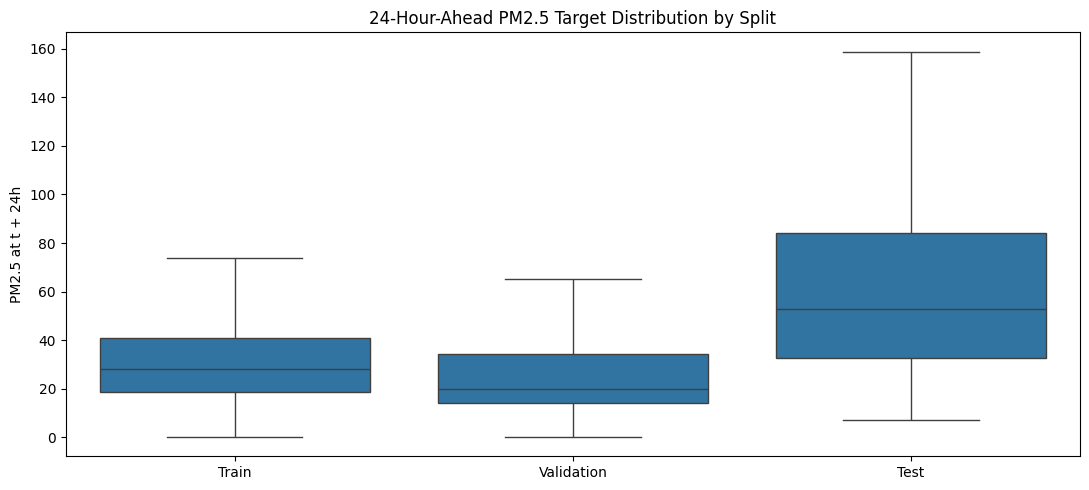

In [63]:
plt.figure(
    figsize=(11, 5)
)

sns.boxplot(
    data=plot_df,
    x='split',
    y='target_pm25_24h',
    showfliers=False
)

plt.title(
    '24-Hour-Ahead PM2.5 Target Distribution by Split'
)

plt.xlabel('')
plt.ylabel(
    'PM2.5 at t + 24h'
)

plt.tight_layout()
plt.show()

## Baseline evaluation

In [64]:
#Metric helper
def regression_metrics(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

In [65]:
#Baseline evaluation helper
def evaluate_baselines(
    df
):

    y = df[
        'target_pm25_24h'
    ]

    results = {}

    baselines = {
        'Persistence_24h':
            'baseline_persistence',

        'Weekly_Seasonal':
            'baseline_weekly',

        'Trailing_24h_Mean':
            'baseline_24h_mean'
    }

    for name, column in (
        baselines.items()
    ):

        results[
            name
        ] = regression_metrics(
            y,
            df[column]
        )

    return (
        pd.DataFrame(
            results
        )
        .T
    )

In [66]:
#Validation baseline performance
validation_baselines = (
    evaluate_baselines(
        validation_df
    )
)

validation_baselines.round(
    3
)

,MAE,RMSE,R2
Persistence_24h,7.212,10.912,0.801
Weekly_Seasonal,14.113,21.104,0.255
Trailing_24h_Mean,10.029,16.050,0.569


In [67]:
#Test baseline performance
test_baselines = (
    evaluate_baselines(
        test_df
    )
)

test_baselines.round(
    3
)

,MAE,RMSE,R2
Persistence_24h,12.085,16.284,0.738
Weekly_Seasonal,19.228,25.563,0.353
Trailing_24h_Mean,24.339,29.749,0.124


In [68]:
#Baseline residuals
validation_df[
    'persistence_error'
] = (
    validation_df[
        'target_pm25_24h'
    ]
    -
    validation_df[
        'baseline_persistence'
    ]
)

In [69]:
validation_df[
    'persistence_error'
].describe()

count    3451.000000
mean        0.318082
std        10.909386
min       -56.100000
25%        -4.500000
50%         0.300000
75%         5.200000
max        84.000000
Name: persistence_error, dtype: float64

## TimeSeriesSplit for future model tuning

In [70]:
tscv = TimeSeriesSplit(
    n_splits=5,
    gap=FORECAST_HORIZON
)

In [71]:
cv_rows = []

for fold, (
    train_idx,
    val_idx
) in enumerate(
    tscv.split(
        train_df
    ),
    start=1
):

    fold_train = (
        train_df.iloc[
            train_idx
        ]
    )

    fold_val = (
        train_df.iloc[
            val_idx
        ]
    )

    cv_rows.append({
        'fold':
            fold,

        'train_rows':
            len(fold_train),

        'train_start':
            fold_train.index.min(),

        'train_end':
            fold_train.index.max(),

        'validation_rows':
            len(fold_val),

        'validation_start':
            fold_val.index.min(),

        'validation_end':
            fold_val.index.max()
    })


cv_summary = pd.DataFrame(
    cv_rows
)

cv_summary

,fold,train_rows,train_start,train_end,validation_rows,validation_start,validation_end
0,1,2682,2022-09-08,2022-12-28 17:00:00,2701,2022-12-29 18:00:00,2023-04-21 06:00:00
1,2,5383,2022-09-08,2023-04-20 06:00:00,2701,2023-04-21 07:00:00,2023-08-11 19:00:00
2,3,8084,2022-09-08,2023-08-10 19:00:00,2701,2023-08-11 20:00:00,2023-12-02 08:00:00
3,4,10785,2022-09-08,2023-12-01 08:00:00,2701,2023-12-02 09:00:00,2024-03-23 21:00:00
4,5,13486,2022-09-08,2024-03-22 21:00:00,2701,2024-03-23 22:00:00,2024-07-14 10:00:00


## Create X and Y

In [72]:
#training
X_train = (
    train_df[
        feature_columns
    ].copy()
)

y_train = (
    train_df[
        'target_pm25_24h'
    ].copy()
)

In [73]:
X_validation = (
    validation_df[
        feature_columns
    ].copy()
)

y_validation = (
    validation_df[
        'target_pm25_24h'
    ].copy()
)

In [74]:
X_test = (
    test_df[
        feature_columns
    ].copy()
)

y_test = (
    test_df[
        'target_pm25_24h'
    ].copy()
)

In [75]:
print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_validation.shape,
    y_validation.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

Train: (16211, 55) (16211,)
Validation: (3451, 55) (3451,)
Test: (3450, 55) (3450,)


In [76]:
#forecasting datasets
forecast_df.to_csv(
    ML_DIR /
    "pm25_forecasting_dataset.csv"
)

In [77]:
#Train/validation/test
train_df.to_csv(
    ML_DIR /
    "train.csv"
)

validation_df.to_csv(
    ML_DIR /
    "validation.csv"
)

test_df.to_csv(
    ML_DIR /
    "test.csv"
)

In [78]:
#feature list
feature_table = pd.DataFrame({
    'feature':
        feature_columns
})

feature_table.to_csv(
    TABLES_DIR /
    "forecast_feature_list.csv",
    index=False
)

In [79]:
cv_summary.to_csv(
    TABLES_DIR /
    "time_series_cv_folds.csv",
    index=False
)

In [80]:
validation_baselines.to_csv(
    TABLES_DIR /
    "validation_baselines.csv"
)

test_baselines.to_csv(
    TABLES_DIR /
    "test_baselines.csv"
)

## Final leakage audit

In [81]:
print(
    "Target in features:",
    'target_pm25_24h'
    in feature_columns
)

print(
    "Any feature missing:",
    X_train.isna()
    .any()
    .any()
)

print(
    "Train target missing:",
    y_train.isna()
    .any()
)

print(
    "Validation target missing:",
    y_validation.isna()
    .any()
)

print(
    "Test target missing:",
    y_test.isna()
    .any()
)

Target in features: False
Any feature missing: False
Train target missing: False
Validation target missing: False
Test target missing: False


In [82]:
#chronological ordering
assert (
    X_train.index.is_monotonic_increasing
)

assert (
    X_validation.index.is_monotonic_increasing
)

assert (
    X_test.index.is_monotonic_increasing
)

assert (
    X_train.index.max()
    <
    X_validation.index.min()
)

assert (
    X_validation.index.max()
    <
    X_test.index.min()
)

In [83]:
print(
    "✓ Chronological ordering verified"
)

✓ Chronological ordering verified


In [84]:
print("=" * 76)
print(
    "PHASE 8 — ML FORECASTING PREPARATION SUMMARY"
)
print("=" * 76)

print(
    f"\nForecast horizon: "
    f"{FORECAST_HORIZON} hours"
)

print(
    f"Model features: "
    f"{len(feature_columns)}"
)

print(
    f"\nUsable forecasting rows: "
    f"{len(forecast_df):,}"
)

print(
    f"Rows removed for lags/target: "
    f"{len(ml_df) - len(forecast_df):,}"
)


print("\nTRAIN")
print(
    f"Rows: {len(train_df):,}"
)

print(
    f"{train_df.index.min()} "
    f"to "
    f"{train_df.index.max()}"
)


print("\nVALIDATION")
print(
    f"Rows: "
    f"{len(validation_df):,}"
)

print(
    f"{validation_df.index.min()} "
    f"to "
    f"{validation_df.index.max()}"
)


print("\nTEST")
print(
    f"Rows: "
    f"{len(test_df):,}"
)

print(
    f"{test_df.index.min()} "
    f"to "
    f"{test_df.index.max()}"
)


print(
    "\nVALIDATION BASELINES"
)

print(
    validation_baselines
    .round(3)
)


print(
    "\nTEST BASELINES"
)

print(
    test_baselines
    .round(3)
)


best_validation_baseline = (
    validation_baselines[
        'MAE'
    ]
    .idxmin()
)

print(
    "\nBest validation baseline:",
    best_validation_baseline
)

print(
    "\nTrain target mean:",
    round(
        y_train.mean(),
        2
    )
)

print(
    "Validation target mean:",
    round(
        y_validation.mean(),
        2
    )
)

print(
    "Test target mean:",
    round(
        y_test.mean(),
        2
    )
)

print(
    "\nLeakage checks:"
)

print(
    "Target in features:",
    'target_pm25_24h'
    in feature_columns
)

print(
    "Missing feature values:",
    X_train.isna()
    .sum()
    .sum()
)

print(
    "\n" + "=" * 76
)

PHASE 8 — ML FORECASTING PREPARATION SUMMARY

Forecast horizon: 24 hours
Model features: 55

Usable forecasting rows: 23,160
Rows removed for lags/target: 192

TRAIN
Rows: 16,211
2022-09-08 00:00:00 to 2024-07-14 10:00:00

VALIDATION
Rows: 3,451
2024-07-15 11:00:00 to 2024-12-06 05:00:00

TEST
Rows: 3,450
2024-12-07 06:00:00 to 2025-04-29 23:00:00

VALIDATION BASELINES
                      MAE    RMSE     R2
Persistence_24h     7.212  10.912  0.801
Weekly_Seasonal    14.113  21.104  0.255
Trailing_24h_Mean  10.029  16.050  0.569

TEST BASELINES
                      MAE    RMSE     R2
Persistence_24h    12.085  16.284  0.738
Weekly_Seasonal    19.228  25.563  0.353
Trailing_24h_Mean  24.339  29.749  0.124

Best validation baseline: Persistence_24h

Train target mean: 31.3
Validation target mean: 28.91
Test target mean: 59.25

Leakage checks:
Target in features: False
Missing feature values: 0



## Phase 8 Summary: Forecasting Dataset and Leakage Control

A supervised time-series forecasting dataset was constructed to predict
PM2.5 concentrations 24 hours in advance. Each observation represents a
forecast origin, with the response variable defined as PM2.5 measured
exactly 24 hours later.

Predictors were restricted to information available at or before the
forecast origin. These included current pollutant and meteorological
measurements, lagged PM2.5 concentrations, lagged co-pollutants, historical
rolling PM2.5 statistics, recent meteorological summaries, and calendar
variables known in advance for the target timestamp. Actual future
meteorological observations were deliberately excluded to prevent
look-ahead bias.

Lagged features were motivated by the persistence structure identified in
the time-series analysis. PM2.5 lags at 1, 3, 6, 12, 24, 48, 72, and 168
hours were included, together with rolling means and standard deviations
covering periods from 6 hours to one week.

The dataset was divided chronologically into training, validation, and
test periods. A 24-hour purge gap was inserted between adjacent splits so
that training labels could not overlap subsequent validation or test
forecast origins. Future model tuning will additionally use expanding
TimeSeriesSplit cross-validation with a 24-hour gap.

Three non-machine-learning forecasting baselines were established:
24-hour persistence, a weekly seasonal-naive forecast, and a trailing
24-hour mean. Subsequent machine-learning models will be required to
improve on these baselines, particularly the strong 24-hour persistence
forecast.

No scaling, feature selection, or model fitting was performed using the
complete dataset. Any learned preprocessing in later phases will be fitted
only on training observations or individual time-series training folds.

In [86]:
print(
    "Features:",
    len(feature_columns)
)

print(
    "Forecast rows:",
    len(forecast_df)
)

print(
    split_target_summary.round(2)
)

print(
    validation_baselines.round(3)
)

print(
    test_baselines.round(3)
)

print(
    cv_summary
)

Features: 55
Forecast rows: 23160
          Train  Validation     Test
count  16211.00     3451.00  3450.00
mean      31.30       28.91    59.25
std       16.83       24.46    31.79
min        0.20        0.40     7.40
25%       18.90       14.00    32.90
50%       28.30       19.90    52.70
75%       40.90       34.50    84.25
max      124.80      164.40   170.40
                      MAE    RMSE     R2
Persistence_24h     7.212  10.912  0.801
Weekly_Seasonal    14.113  21.104  0.255
Trailing_24h_Mean  10.029  16.050  0.569
                      MAE    RMSE     R2
Persistence_24h    12.085  16.284  0.738
Weekly_Seasonal    19.228  25.563  0.353
Trailing_24h_Mean  24.339  29.749  0.124
   fold  train_rows train_start           train_end  validation_rows  \
0     1        2682  2022-09-08 2022-12-28 17:00:00             2701   
1     2        5383  2022-09-08 2023-04-20 06:00:00             2701   
2     3        8084  2022-09-08 2023-08-10 19:00:00             2701   
3     4       107

In [87]:
for train_idx, val_idx in tscv.split(train_df):

    fold_train = train_df.iloc[train_idx]
    fold_val = train_df.iloc[val_idx]

    assert (
        fold_train['target_time'].max()
        <
        fold_val.index.min()
    )

print(
    "✓ All CV folds pass target-overlap check"
)

✓ All CV folds pass target-overlap check


## Phase 8 Summary: Leakage-Safe Forecasting Design

A leakage-safe supervised dataset was constructed for forecasting hourly
PM2.5 concentrations 24 hours in advance. After accounting for the
168-hour maximum historical feature window and the 24-hour forecasting
horizon, 23,160 observations remained from the original 23,352-hour
dataset. Fifty-five predictors were constructed using only information
available at or before each forecast origin, together with calendar
information known in advance for the target timestamp.

The forecasting data were divided chronologically into training,
validation, and test periods, with 24-hour purge gaps between adjacent
splits to prevent target overlap. Explicit boundary checks confirmed that
all training target timestamps precede subsequent validation origins and
that validation target timestamps precede test origins. Five-fold
expanding-window time-series cross-validation with an equivalent 24-hour
gap was also defined for subsequent model tuning.

Three non-machine-learning forecasting baselines were evaluated. The
24-hour persistence forecast was substantially stronger than both the
weekly seasonal-naive and trailing-24-hour-mean forecasts. On the
validation period, persistence achieved an MAE of approximately 7.21,
RMSE of 10.91, and R² of 0.80. This establishes a demanding benchmark
that subsequent machine-learning models must exceed.

A substantial temporal distribution shift was observed in the held-out
test period. Mean target PM2.5 increased from approximately 31.3 in the
training period and 28.9 in validation to 59.3 in the test period, while
the test median increased to approximately 52.7. Correspondingly,
persistence-baseline MAE increased from approximately 7.21 during
validation to 12.09 during testing. The test set therefore represents a
challenging higher-pollution future regime rather than an identically
distributed random sample.

The held-out test period will remain locked during model development.
Model and hyperparameter selection will rely on expanding-window
cross-validation and the chronological validation period, after which the
selected model will be evaluated once on the final test period.